# Predictive Workforce Planning Using HR Recruitment Analytics
## Step 3: Forecasting Model

**Objective:** Use historical hiring data and attrition rates to forecast 
future hiring needs by department for 2019–2021.

**Approach:** Two complementary models are used:
- **Model 1 — Linear Regression:** Projects overall hiring trend based on historical annual hire counts
- **Model 2 — Attrition-Based Model:** Estimates replacement hires per department using current headcount and attrition rates

**Input:** `../data/processed/HRDataset_Cleaned.csv`

##  Import Libraries

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneOut, cross_val_score
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Libraries imported successfully")

Libraries imported successfully


## Load Cleaned Dataset

In [23]:
df = pd.read_csv('../data/processed/HRDataset_Cleaned.csv')

# Re-parse date columns
df['DateofHire']        = pd.to_datetime(df['DateofHire'],        errors='coerce')
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Active Employees  : {df['IsActive'].sum()}")
print(f"Terminated        : {(df['IsActive'] == 0).sum()}")
print(f"Hire Year Range   : {df['HireYear'].min()} – {df['HireYear'].max()}")

Dataset loaded: 311 rows × 41 columns
Active Employees  : 207
Terminated        : 104
Hire Year Range   : 2006 – 2018


---
## 1. Prepare Annual Hiring Data

Before building any model, we prepare the core time series —
annual hire counts from the dataset.

We use **2011–2016** as the training window because:
- 2006–2010 has very few hires (1–9 per year) — likely incomplete records
- 2017–2018 tails off sharply — data collection may be incomplete for those years
- 2011–2016 represents the most complete and consistent hiring activity

## Prepare Annual Hiring Series

In [24]:
# Overall annual hire counts
annual_hires = df['HireYear'].value_counts().sort_index()

# Training window: 2011–2016 (most reliable data range)
train = annual_hires[(annual_hires.index >= 2011) & (annual_hires.index <= 2016)]

# 3-year moving average baseline (used as fallback for negative forecasts)
moving_avg_baseline = round(train.rolling(3).mean().dropna().iloc[-1], 1)

print("Full Annual Hire Counts:")
print(annual_hires.to_string())
print(f"\nTraining Window (2011–2016):")
print(train.to_string())
print(f"\nTotal hires in training window : {train.sum()}")
print(f"Average hires per year         : {train.mean():.1f}")
print(f"3-Year Moving Avg Baseline     : {moving_avg_baseline}")

Full Annual Hire Counts:
HireYear
2006     1
2007     2
2008     3
2009     7
2010     9
2011    83
2012    45
2013    44
2014    60
2015    36
2016    14
2017     6
2018     1

Training Window (2011–2016):
HireYear
2011    83
2012    45
2013    44
2014    60
2015    36
2016    14

Total hires in training window : 282
Average hires per year         : 47.0
3-Year Moving Avg Baseline     : 36.7


---
## 2. Model 1 — Linear Regression on Annual Hiring Trend

Linear Regression fits a straight line through historical hire counts
to project the direction of hiring in future years.

**Formula:** `Predicted Hires = slope × Year + intercept`

A **negative slope** means hiring is declining over time.
A **positive slope** means hiring is growing.

## Fit Linear Regression Model

In [25]:
# Prepare training data
X_train = train.index.values.reshape(-1, 1)   # Years as feature
y_train = train.values                          # Hire counts as target

# Fit model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Training metrics
y_pred_train = model_lr.predict(X_train)
r2   = r2_score(y_train, y_pred_train)
mae  = mean_absolute_error(y_train, y_pred_train)
rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
mape = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100

print("=" * 45)
print("LINEAR REGRESSION MODEL RESULTS")
print("=" * 45)
print(f"  Slope (trend per year) : {model_lr.coef_[0]:.2f}")
print(f"  Intercept              : {model_lr.intercept_:.2f}")
print(f"  R² Score               : {r2:.3f}")
print(f"  MAE                    : {mae:.2f} hires")
print(f"  RMSE                   : {rmse:.2f} hires")
print(f"  MAPE                   : {mape:.1f}%")
print()
print("Interpretation:")
if model_lr.coef_[0] < 0:
    print(f"  Hiring is declining by ~{abs(model_lr.coef_[0]):.1f} hires per year")
else:
    print(f"  Hiring is growing by ~{model_lr.coef_[0]:.1f} hires per year")
print(f"  R²={r2:.3f} — model explains {r2*100:.1f}% of hiring variance")

LINEAR REGRESSION MODEL RESULTS
  Slope (trend per year) : -10.17
  Intercept              : 20527.17
  R² Score               : 0.674
  MAE                    : 10.97 hires
  RMSE                   : 12.09 hires
  MAPE                   : 27.6%

Interpretation:
  Hiring is declining by ~10.2 hires per year
  R²=0.674 — model explains 67.4% of hiring variance


---
## 3. Model Accuracy Evaluation — Linear Regression

We evaluate the model using standard regression metrics and
**Leave-One-Out Cross Validation (LOO-CV)** — the best technique
for very small datasets (6 data points).

LOO-CV trains on 5 years and tests on 1 year, repeated 6 times.
This shows how well the model generalises to unseen years.

| Metric | What It Measures |
|---|---|
| **R²** | % of variance explained — closer to 1.0 is better |
| **MAE** | Average error in number of hires — lower is better |
| **RMSE** | Penalises large errors more than MAE |
| **MAPE** | Error as % of actual values |
| **LOO-CV MAE** | Generalisation error on unseen years |

## LOO Cross Validation

In [26]:
# Leave-One-Out Cross Validation
# R² is undefined for single-sample test sets — use MAE instead
loo = LeaveOneOut()
loo_mae_scores = -cross_val_score(
    model_lr, X_train, y_train,
    cv=loo,
    scoring='neg_mean_absolute_error'
)

print("=" * 50)
print("LEAVE-ONE-OUT CROSS VALIDATION (LOO-CV)")
print("=" * 50)
print(f"  {'Year Left Out':<16} {'MAE':>8}")
print(f"  {'-'*26}")
for year, score in zip(train.index, loo_mae_scores):
    print(f"  {year:<16} {score:>8.2f} hires")

print(f"\n  LOO-CV Mean MAE : {loo_mae_scores.mean():.2f} hires")
print(f"  LOO-CV Std MAE  : {loo_mae_scores.std():.2f} hires")
print(f"  Training MAE    : {mae:.2f} hires")
print()
print("  Interpretation:")
print(f"  On unseen years the model is off by ~{loo_mae_scores.mean():.0f} hires on average.")
if loo_mae_scores.mean() > mae * 1.5:
    print("Gap between train MAE and LOO-CV MAE is expected")
    print("with only 6 data points — not a code error.")
else:
    print("Train and CV errors are close — model is stable.")

LEAVE-ONE-OUT CROSS VALIDATION (LOO-CV)
  Year Left Out         MAE
  --------------------------
  2011                22.20 hires
  2012                24.49 hires
  2013                 9.87 hires
  2014                22.08 hires
  2015                 6.04 hires
  2016                15.90 hires

  LOO-CV Mean MAE : 16.76 hires
  LOO-CV Std MAE  : 6.84 hires
  Training MAE    : 10.97 hires

  Interpretation:
  On unseen years the model is off by ~17 hires on average.
Gap between train MAE and LOO-CV MAE is expected
with only 6 data points — not a code error.


## Per-Department Accuracy Metrics

In [27]:
dept_year = df.groupby(['HireYear', 'Department']).size().unstack(fill_value=0)
dept_core = dept_year.loc[2011:2016]
top_depts = ['Production', 'IT/IS', 'Sales', 'Software Engineering']

print("=" * 65)
print("PER-DEPARTMENT LINEAR REGRESSION — ACCURACY METRICS")
print("=" * 65)
print(f"{'Department':<24} {'R²':>6} {'MAE':>7} {'RMSE':>7} {'MAPE':>8}")
print("-" * 56)

dept_metrics = []
for dept in top_depts:
    Xd  = dept_core.index.values.reshape(-1, 1)
    yd  = dept_core[dept].values
    md  = LinearRegression().fit(Xd, yd)
    ypd = md.predict(Xd)

    r2d    = r2_score(yd, ypd)
    maed   = mean_absolute_error(yd, ypd)
    rmsed  = np.sqrt(mean_squared_error(yd, ypd))
    mape_d = np.mean(np.abs((yd - ypd) / np.where(yd == 0, 1, yd))) * 100

    print(f"{dept:<24} {r2d:>6.3f} {maed:>7.2f} {rmsed:>7.2f} {mape_d:>7.1f}%")
    dept_metrics.append({
        'Department': dept, 'R2': round(r2d, 3),
        'MAE': round(maed, 2), 'RMSE': round(rmsed, 2),
        'MAPE_pct': round(mape_d, 1)
    })

print()
print("  Interpretation:")
print("  R² ≥ 0.70 -> strong fit    (Production, Software Engineering)")
print("  R² < 0.40 -> weak fit      (IT/IS, Sales — use attrition model instead)")
print()

dept_metrics_df = pd.DataFrame(dept_metrics)
print(f"\ndept_metrics_df ready — {len(dept_metrics_df)} departments")

PER-DEPARTMENT LINEAR REGRESSION — ACCURACY METRICS
Department                   R²     MAE    RMSE     MAPE
--------------------------------------------------------
Production                0.826    6.80    8.45    26.3%
IT/IS                     0.280    4.33    5.48   129.4%
Sales                     0.180    2.19    3.02    67.8%
Software Engineering      0.812    0.56    0.63    31.0%

  Interpretation:
  R² ≥ 0.70 -> strong fit    (Production, Software Engineering)
  R² < 0.40 -> weak fit      (IT/IS, Sales — use attrition model instead)


dept_metrics_df ready — 4 departments


## Accuracy Visualisation

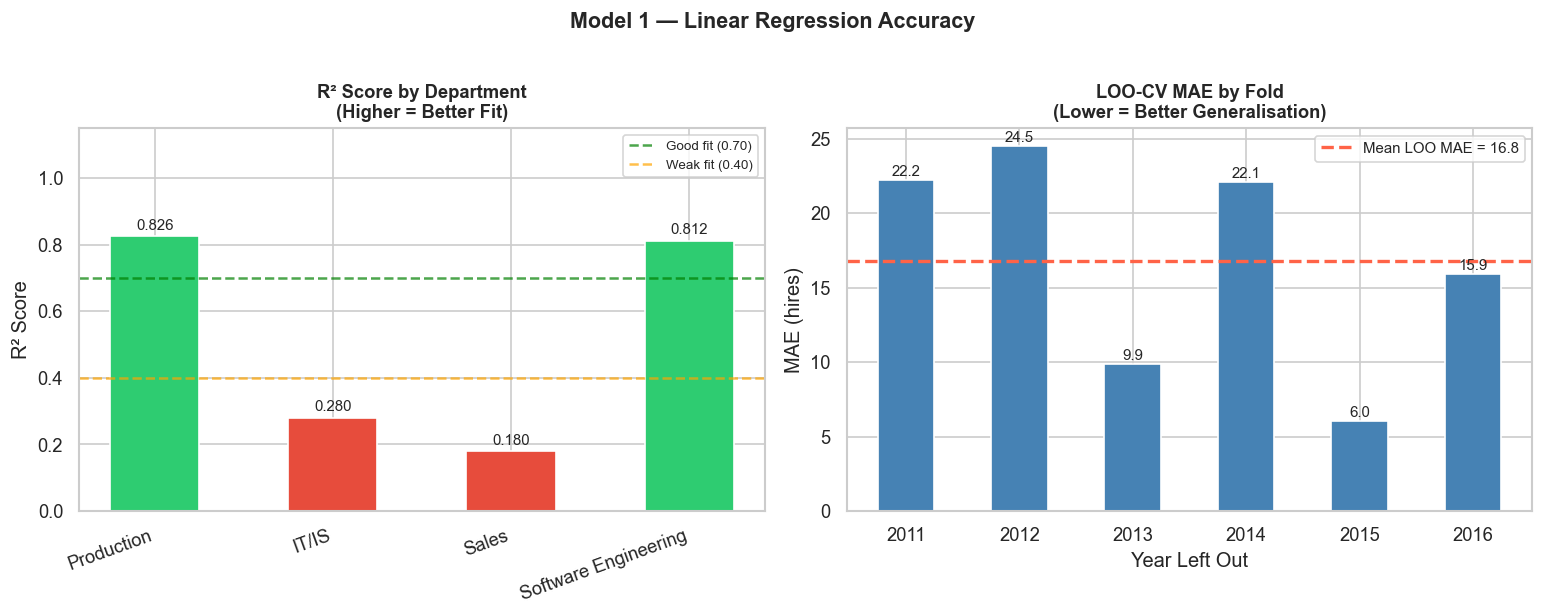

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: R² per department ---
ax1 = axes[0]
colors_r2 = ['#2ecc71' if r >= 0.7 else '#e67e22' if r >= 0.4 else '#e74c3c'
              for r in dept_metrics_df['R2']]
bars = ax1.bar(dept_metrics_df['Department'], dept_metrics_df['R2'],
               color=colors_r2, edgecolor='white', width=0.5)
ax1.axhline(y=0.7, color='green', linestyle='--',
            linewidth=1.5, alpha=0.7, label='Good fit (0.70)')
ax1.axhline(y=0.4, color='orange', linestyle='--',
            linewidth=1.5, alpha=0.7, label='Weak fit (0.40)')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f"{bar.get_height():.3f}", ha='center', fontsize=9)
ax1.set_title('R² Score by Department\n(Higher = Better Fit)',
              fontsize=11, fontweight='bold')
ax1.set_ylabel('R² Score')
ax1.set_ylim(0, 1.15)
ax1.legend(fontsize=8)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=20, ha='right')

# --- Right: LOO-CV MAE per fold ---
ax2 = axes[1]
bars2 = ax2.bar(train.index, loo_mae_scores,
                color='steelblue', edgecolor='white', width=0.5)
ax2.axhline(y=loo_mae_scores.mean(), color='tomato', linestyle='--',
            linewidth=2, label=f'Mean LOO MAE = {loo_mae_scores.mean():.1f}')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{bar.get_height():.1f}", ha='center', fontsize=9)
ax2.set_title('LOO-CV MAE by Fold\n(Lower = Better Generalisation)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Year Left Out')
ax2.set_ylabel('MAE (hires)')
ax2.legend(fontsize=9)

plt.suptitle('Model 1 — Linear Regression Accuracy',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/10_model_accuracy.png', bbox_inches='tight')
plt.show()

---
## 4. Generate Forecast — Model 1 (Linear Regression)

The regression line has a **negative slope of -10.17** meaning hiring 
has been declining sharply since 2011. By 2019 the raw prediction 
goes below zero — which is mathematically correct but not a useful 
hiring target.

We therefore present:
- The **raw regression prediction** (shows the declining trend direction)
- The **3-year moving average baseline** (used as the adjusted hiring target)

## Generate Forecast (2019–2021)

In [29]:
# Forecast years
forecast_years = np.array([2019, 2020, 2021]).reshape(-1, 1)

# Raw predictions (may be negative due to declining trend)
raw_preds = model_lr.predict(forecast_years)

# Clipped to 0 (can't have negative hires)
forecast_lr = np.clip(raw_preds, 0, None).round(1)

# Build forecast table
forecast_df = pd.DataFrame({
    'Year'               : [2019, 2020, 2021],
    'Raw_Prediction'     : raw_preds.round(1),
    'Clipped_Forecast'   : forecast_lr,
    'MovingAvg_Baseline' : moving_avg_baseline
})

print("Linear Regression Forecast:")
print(forecast_df.to_string(index=False))
print()
print(f"Raw predictions are negative — the declining trend line goes")
print(f"below zero by 2019 due to the sharp drop from 83 hires in 2011")
print(f"to 14 hires in 2016.")
print(f"\n3-Year Moving Average Baseline : {moving_avg_baseline:.0f} hires/year")
print(f"-> This is used as the adjusted planning baseline.")
print(f"-> Use attrition model for department-level targets.")

Linear Regression Forecast:
 Year  Raw_Prediction  Clipped_Forecast  MovingAvg_Baseline
 2019            -8.9               0.0                36.7
 2020           -19.1               0.0                36.7
 2021           -29.3               0.0                36.7

Raw predictions are negative — the declining trend line goes
below zero by 2019 due to the sharp drop from 83 hires in 2011
to 14 hires in 2016.

3-Year Moving Average Baseline : 37 hires/year
-> This is used as the adjusted planning baseline.
-> Use attrition model for department-level targets.


## Plot Linear Regression Forecast

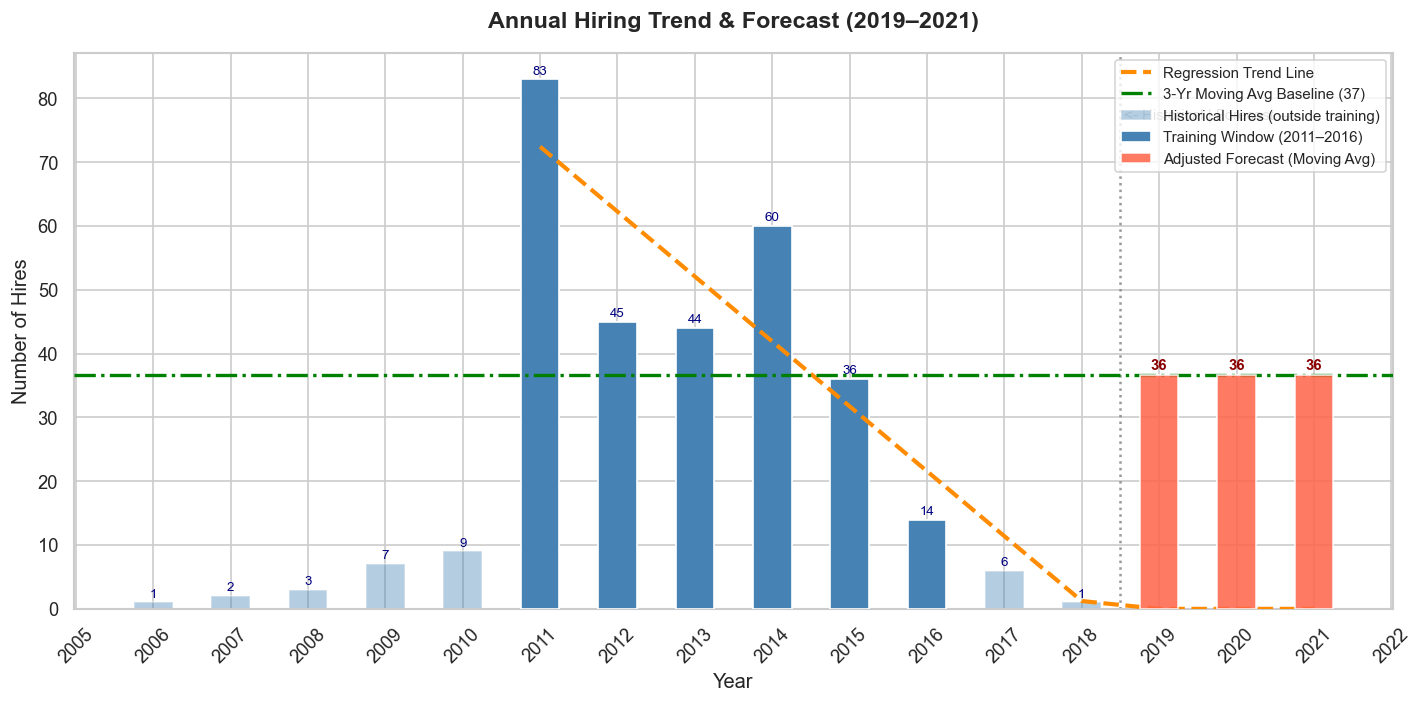

In [30]:
all_years      = annual_hires.index.values
all_hires      = annual_hires.values
train_years    = train.index.values
forecast_yrs   = [2019, 2020, 2021]
forecast_vals  = forecast_lr

# Regression line over full range
line_years = np.arange(2011, 2022).reshape(-1, 1)
line_preds = np.clip(model_lr.predict(line_years), 0, None)

fig, ax = plt.subplots(figsize=(12, 6))

# All historical bars (light)
ax.bar(all_years, all_hires, color='steelblue', alpha=0.4,
       width=0.5, label='Historical Hires (outside training)', zorder=2)

# Training window highlight (dark)
ax.bar(train_years, train.values, color='steelblue', alpha=1.0,
       width=0.5, label='Training Window (2011–2016)', zorder=3)

# Regression trend line
ax.plot(line_years, line_preds, color='darkorange', linewidth=2.5,
        linestyle='--', label='Regression Trend Line', zorder=4)

# Moving average baseline line
ax.axhline(y=moving_avg_baseline, color='green', linewidth=2,
           linestyle='-.', label=f'3-Yr Moving Avg Baseline ({moving_avg_baseline:.0f})', zorder=4)

# Forecast bars (using moving avg since regression = 0)
ax.bar(forecast_yrs, [moving_avg_baseline] * 3,
       color='tomato', alpha=0.85, width=0.5,
       label='Adjusted Forecast (Moving Avg)', zorder=5)

# Value labels — historical
for y, v in zip(all_years, all_hires):
    ax.text(y, v + 0.8, str(int(v)), ha='center', fontsize=8, color='navy')

# Value labels — forecast
for y in forecast_yrs:
    ax.text(y, moving_avg_baseline + 0.8, str(int(moving_avg_baseline)),
            ha='center', fontsize=9, fontweight='bold', color='darkred')

# Divider
ax.axvline(x=2018.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2018.55, ax.get_ylim()[1] * 0.88,
        '<- Historical | Forecast →', fontsize=9, color='gray')

ax.set_title('Annual Hiring Trend & Forecast (2019–2021)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Hires')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/11_linear_regression_forecast.png', bbox_inches='tight')
plt.show()

---
## 5. Model 2 — Attrition-Based Replacement Forecast

This model estimates **how many new hires each department will need**
to replace employees who are expected to leave, based on their
historical attrition rate.

**Formula:**
> `Predicted Replacement Hires = Active Headcount × Attrition Rate`

This is more actionable than the overall trend model because it
gives **department-level hiring targets**, not just an overall number.

## Build Attrition Model

In [31]:
# Calculate per-department attrition metrics
attrition_model = df.groupby('Department').agg(
    TotalEver    = ('EmpID',    'count'),
    ActiveNow    = ('IsActive', 'sum'),
    Terminated   = ('IsActive', lambda x: (x == 0).sum()),
    AvgTenure    = ('TenureYears', 'mean')
).round(2).reset_index()

attrition_model['AttritionRate']     = (attrition_model['Terminated'] /
                                         attrition_model['TotalEver']).round(3)
attrition_model['AttritionRate_Pct'] = (attrition_model['AttritionRate'] * 100).round(1)

# Predicted annual replacement hires per department
attrition_model['Predicted_Hires_Yr1'] = (
    attrition_model['ActiveNow'] * attrition_model['AttritionRate']
).round(1)

print("=" * 65)
print("ATTRITION-BASED FORECAST MODEL")
print("=" * 65)
print(attrition_model[['Department', 'ActiveNow', 'AttritionRate_Pct',
                         'AvgTenure', 'Predicted_Hires_Yr1']].to_string(index=False))
print(f"\nTotal predicted replacement hires (Year 1): "
      f"{attrition_model['Predicted_Hires_Yr1'].sum():.1f}")

ATTRITION-BASED FORECAST MODEL
          Department  ActiveNow  AttritionRate_Pct  AvgTenure  Predicted_Hires_Yr1
       Admin Offices          7               22.2       4.68                  1.6
    Executive Office          1                0.0       6.50                  0.0
               IT/IS         40               20.0       3.68                  8.0
          Production        126               39.7       4.85                 50.0
               Sales         26               16.1       5.35                  4.2
Software Engineering          7               36.4       5.00                  2.5

Total predicted replacement hires (Year 1): 66.3


## Attrition Model — Accuracy Check

We compare the attrition model predictions against actual average
annual exits in 2015–2016 (the two most recent complete years).

> Note: The attrition model forecasts **total replacement hires needed**
> based on the full historical attrition rate — not just 1–2 years of exits.
> It intentionally forecasts higher to cover future workforce planning needs.

## Attrition Model Accuracy

In [32]:
# Actual average annual exits in 2015-2016
df['TermYear'] = df['DateofTermination'].dt.year
actual_exits = (
    df[df['TermYear'].isin([2015, 2016])]
    .groupby('Department').size() / 2
)

print("=" * 70)
print("MODEL 2 — ATTRITION ACCURACY CHECK (vs 2015–2016 Avg Exits)")
print("=" * 70)
print(f"{'Department':<24} {'Predicted':>10} {'Actual Exits':>14} "
      f"{'Error':>8} {'% Error':>9}")
print("-" * 70)

attrition_pct_errors = []
for dept in ['Production', 'IT/IS', 'Sales', 'Software Engineering']:
    pred   = attrition_model.set_index('Department').loc[dept, 'Predicted_Hires_Yr1']
    actual = actual_exits.get(dept, 0)
    error  = abs(pred - actual)
    pct_e  = (error / actual * 100) if actual > 0 else 0
    attrition_pct_errors.append(pct_e)
    print(f"{dept:<24} {pred:>10.1f} {actual:>14.1f} {error:>8.1f} {pct_e:>8.1f}%")

print()
print("  Note: High % errors are expected — the model uses the full")
print("  historical attrition rate (2011–2018), not just 2015–2016.")
print("  It is designed for planning targets, not exact exit matching.")

MODEL 2 — ATTRITION ACCURACY CHECK (vs 2015–2016 Avg Exits)
Department                Predicted   Actual Exits    Error   % Error
----------------------------------------------------------------------
Production                     50.0           16.5     33.5    203.0%
IT/IS                           8.0            4.0      4.0    100.0%
Sales                           4.2            0.5      3.7    740.0%
Software Engineering            2.5            1.0      1.5    150.0%

  Note: High % errors are expected — the model uses the full
  historical attrition rate (2011–2018), not just 2015–2016.
  It is designed for planning targets, not exact exit matching.


## Attrition Forecast Chart

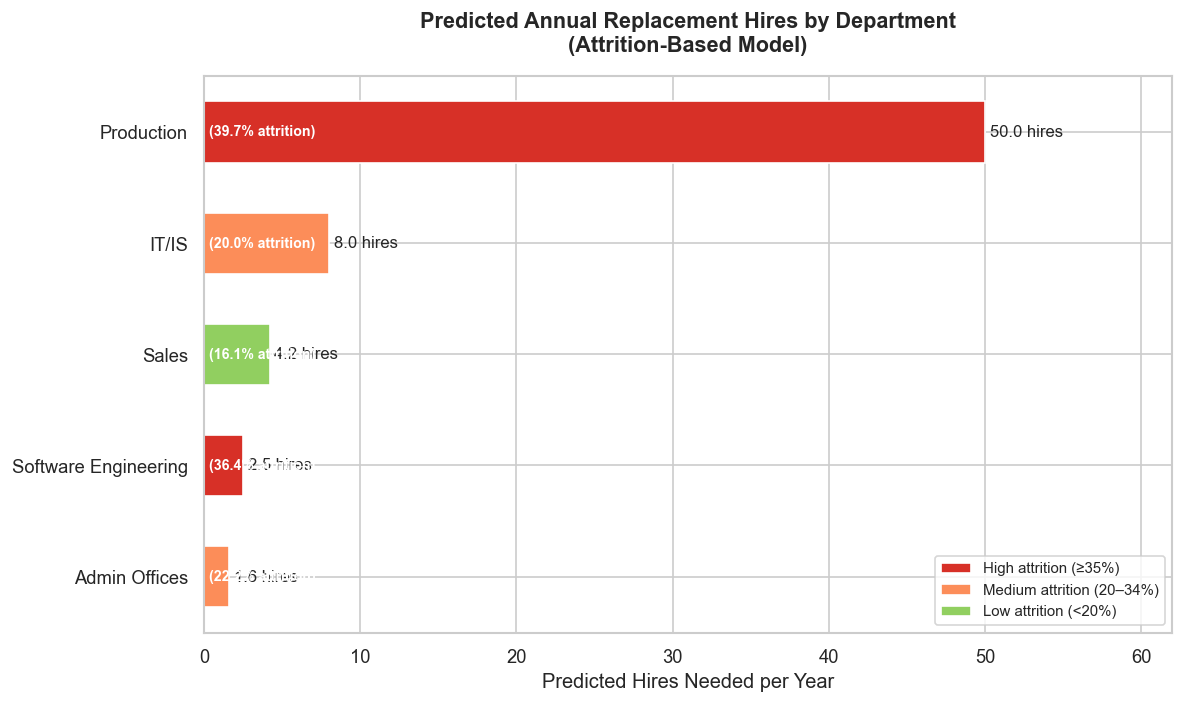

In [33]:
# Exclude Executive Office (only 1 employee, and it is not meaningful)
plot_df = attrition_model[attrition_model['Department'] != 'Executive Office'].copy()
plot_df = plot_df.sort_values('Predicted_Hires_Yr1', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#d73027' if r >= 35 else '#fc8d59' if r >= 20 else '#91cf60'
          for r in plot_df['AttritionRate_Pct']]
bars = ax.barh(plot_df['Department'], plot_df['Predicted_Hires_Yr1'],
               color=colors, edgecolor='white', height=0.55)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{w:.1f} hires", va='center', fontsize=10)

# Add attrition % annotations
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(0.3, i, f"({row['AttritionRate_Pct']}% attrition)",
            va='center', fontsize=8.5, color='white', fontweight='bold')

ax.set_title('Predicted Annual Replacement Hires by Department\n(Attrition-Based Model)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Hires Needed per Year')
ax.set_xlim(0, plot_df['Predicted_Hires_Yr1'].max() + 12)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d73027', label='High attrition (≥35%)'),
                   Patch(facecolor='#fc8d59', label='Medium attrition (20–34%)'),
                   Patch(facecolor='#91cf60', label='Low attrition (<20%)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/12_attrition_forecast_by_dept.png', bbox_inches='tight')
plt.show()

---
## 6. Department-Level Regression Forecast

Apply Linear Regression to each department individually to see
if any department shows a growing or declining hiring trend.

This helps identify which departments need **proactive hiring** 
(growing trend) vs **retention focus** (declining trend).

## Per-Department Regression

In [34]:
forecast_years_arr = np.array([2019, 2020, 2021]).reshape(-1, 1)
dept_forecast_results = []

print("=" * 65)
print("PER-DEPARTMENT LINEAR REGRESSION RESULTS")
print("=" * 65)

for dept in top_depts:
    Xd = dept_core.index.values.reshape(-1, 1)
    yd = dept_core[dept].values
    md = LinearRegression().fit(Xd, yd)

    r2d   = r2_score(yd, md.predict(Xd))
    maed  = mean_absolute_error(yd, md.predict(Xd))
    preds_d = np.clip(md.predict(forecast_years_arr), 0, None).round(1)

    print(f"\n{dept}")
    print(f"   Slope (trend/yr) : {md.coef_[0]:.2f}")
    print(f"   R² Score         : {r2d:.3f}")
    print(f"   MAE              : {maed:.2f}")
    print(f"   Forecast 2019    : {preds_d[0]:.1f} hires")
    print(f"   Forecast 2020    : {preds_d[1]:.1f} hires")
    print(f"   Forecast 2021    : {preds_d[2]:.1f} hires")

    for yr, pred in zip([2019, 2020, 2021], preds_d):
        dept_forecast_results.append({
            'Department': dept,
            'Year': yr,
            'Predicted_Hires': pred,
            'Slope': round(md.coef_[0], 2),
            'R2': round(r2d, 3)
        })

dept_forecast_df = pd.DataFrame(dept_forecast_results)

PER-DEPARTMENT LINEAR REGRESSION RESULTS

Production
   Slope (trend/yr) : -10.80
   R² Score         : 0.826
   MAE              : 6.80
   Forecast 2019    : 0.0 hires
   Forecast 2020    : 0.0 hires
   Forecast 2021    : 0.0 hires

IT/IS
   Slope (trend/yr) : 2.00
   R² Score         : 0.280
   MAE              : 4.33
   Forecast 2019    : 18.0 hires
   Forecast 2020    : 20.0 hires
   Forecast 2021    : 22.0 hires

Sales
   Slope (trend/yr) : -0.83
   R² Score         : 0.180
   MAE              : 2.19
   Forecast 2019    : 0.3 hires
   Forecast 2020    : 0.0 hires
   Forecast 2021    : 0.0 hires

Software Engineering
   Slope (trend/yr) : -0.77
   R² Score         : 0.812
   MAE              : 0.56
   Forecast 2019    : 0.0 hires
   Forecast 2020    : 0.0 hires
   Forecast 2021    : 0.0 hires


## Department Forecast Chart

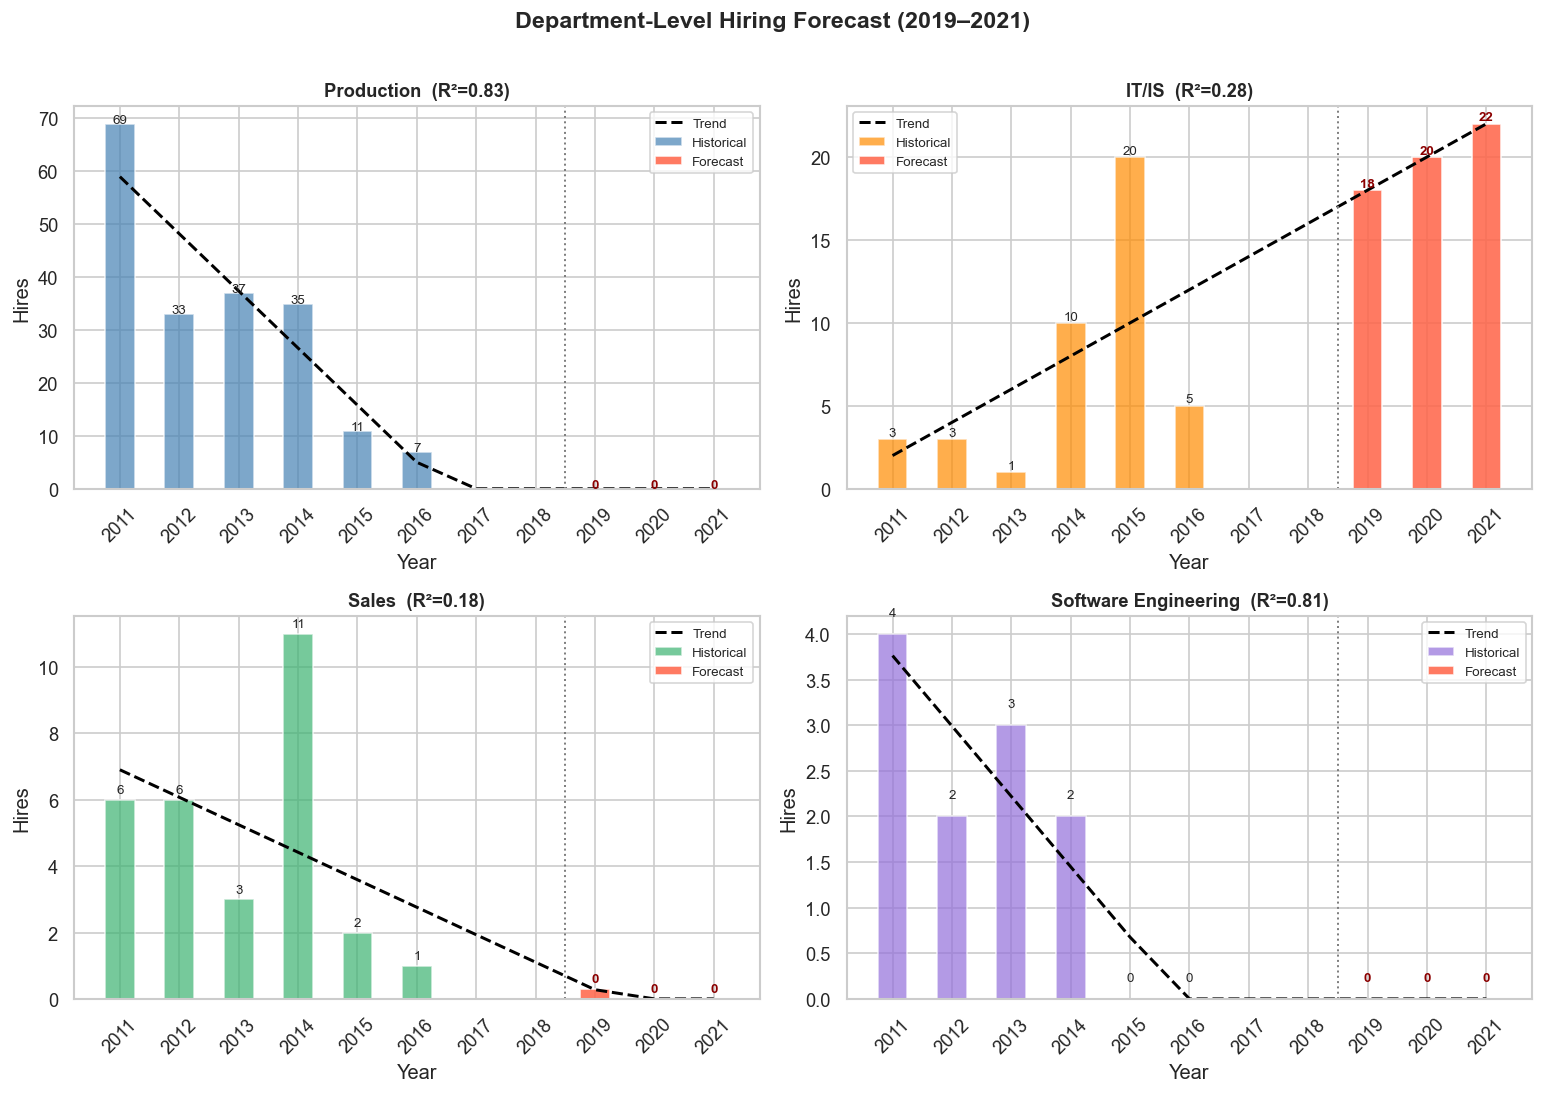

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
palette = ['steelblue', 'darkorange', 'mediumseagreen', 'mediumpurple']

for idx, dept in enumerate(top_depts):
    ax = axes[idx]

    # Historical
    hist = dept_core[dept]
    Xd   = hist.index.values.reshape(-1, 1)
    yd   = hist.values
    md   = LinearRegression().fit(Xd, yd)

    # Trend line
    line_x = np.arange(2011, 2022).reshape(-1, 1)
    line_y = np.clip(md.predict(line_x), 0, None)

    # Forecast
    f_preds = np.clip(md.predict(forecast_years_arr), 0, None).round(1)

    ax.bar(hist.index, hist.values, color=palette[idx],
           alpha=0.7, width=0.5, label='Historical')
    ax.bar([2019, 2020, 2021], f_preds, color='tomato',
           alpha=0.85, width=0.5, label='Forecast')
    ax.plot(line_x, line_y, color='black', linewidth=1.8,
            linestyle='--', label='Trend')
    ax.axvline(x=2018.5, color='gray', linestyle=':', linewidth=1.2)

    # Labels
    for y, v in zip(hist.index, hist.values):
        ax.text(y, v + 0.2, str(int(v)), ha='center', fontsize=8)
    for y, v in zip([2019, 2020, 2021], f_preds):
        ax.text(y, v + 0.2, str(int(v)), ha='center', fontsize=8,
                fontweight='bold', color='darkred')

    r2d = r2_score(yd, md.predict(Xd))
    ax.set_title(f"{dept}  (R²={r2d:.2f})", fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Hires')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.legend(fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Department-Level Hiring Forecast (2019–2021)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/13_dept_regression_forecast.png', bbox_inches='tight')
plt.show()

---
## 7. Combined Forecast Summary Table

Combining both models gives a balanced view:
- **Regression forecast** reflects the historical hiring trend
- **Attrition forecast** reflects replacement need based on current headcount

The **higher of the two** values should be used as the recommended 
hiring target — it covers both trend and replacement demand.

In [36]:
# Attrition model values — indexed by Department
attrition_vals = attrition_model.set_index('Department')['Predicted_Hires_Yr1']
attrition_rate = attrition_model.set_index('Department')['AttritionRate_Pct']
active_now     = attrition_model.set_index('Department')['ActiveNow']

# Regression model values for 2019
reg_vals = (dept_forecast_df[dept_forecast_df['Year'] == 2019]
            .set_index('Department')['Predicted_Hires'])

# Build summary using attrition index as base (covers all 6 departments)
summary = pd.DataFrame({
    'Active_Headcount'   : active_now,
    'Attrition_Rate_%'   : attrition_rate,
    'Attrition_Forecast' : attrition_vals,
    'Regression_Forecast': reg_vals
}).fillna(0).round(1)

summary['Recommended_Hires'] = (
    summary[['Attrition_Forecast', 'Regression_Forecast']]
    .max(axis=1).round(1)
)
summary['Priority'] = summary['Attrition_Rate_%'].apply(
    lambda x: 'High'   if x >= 35 else
              'Medium' if x >= 20 else 'Low'
)

print("=" * 78)
print("COMBINED FORECAST SUMMARY — RECOMMENDED HIRES (NEXT YEAR)")
print("=" * 78)
print(summary[['Active_Headcount', 'Attrition_Rate_%',
               'Attrition_Forecast', 'Regression_Forecast',
               'Recommended_Hires', 'Priority']].to_string())
print(f"\nTotal Recommended Hires (Organisation-wide): "
      f"{summary['Recommended_Hires'].sum():.0f}")

COMBINED FORECAST SUMMARY — RECOMMENDED HIRES (NEXT YEAR)
                      Active_Headcount  Attrition_Rate_%  Attrition_Forecast  Regression_Forecast  Recommended_Hires Priority
Department                                                                                                                   
Admin Offices                        7              22.2                 1.6                  0.0                1.6   Medium
Executive Office                     1               0.0                 0.0                  0.0                0.0      Low
IT/IS                               40              20.0                 8.0                 18.0               18.0   Medium
Production                         126              39.7                50.0                  0.0               50.0     High
Sales                               26              16.1                 4.2                  0.3                4.2      Low
Software Engineering                 7              36.4    

## Combined Forecast Bar Chart

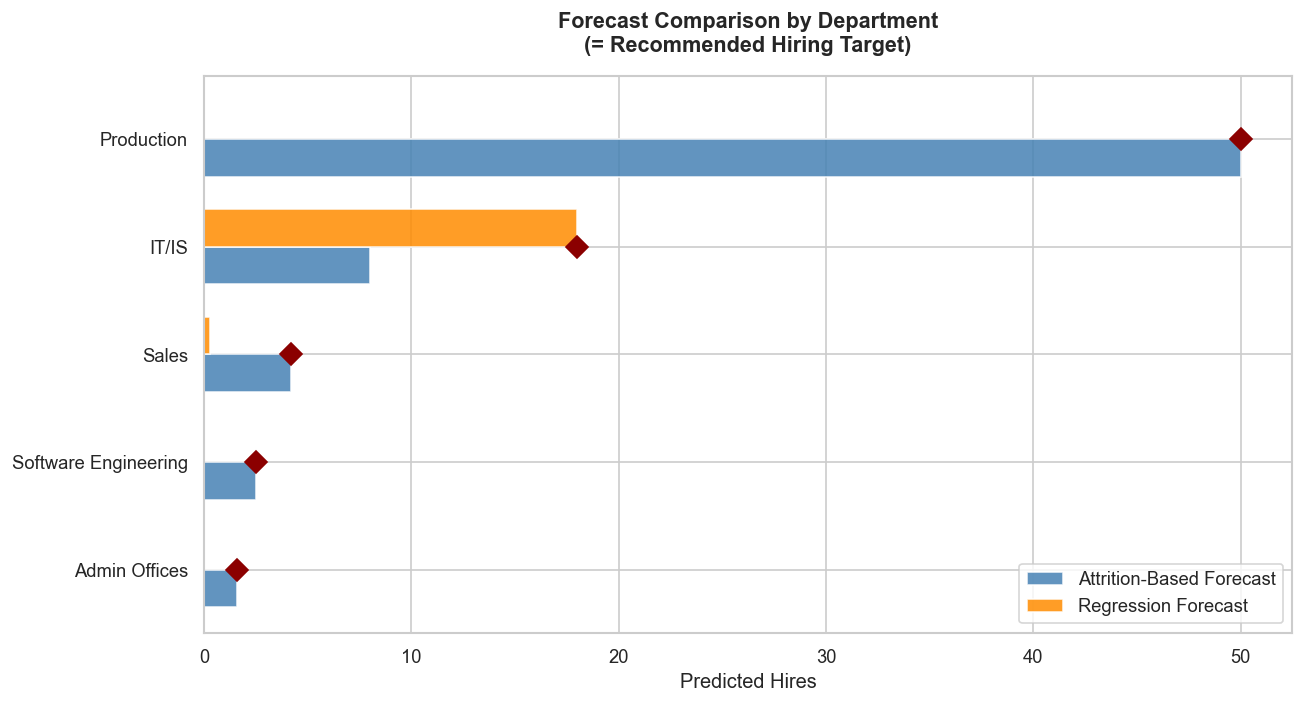

In [37]:
plot_summary = summary[summary.index != 'Executive Office'].copy()
plot_summary = plot_summary.sort_values('Recommended_Hires', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(plot_summary))
width = 0.35

ax.barh(x - width/2, plot_summary['Attrition_Forecast'],
                width, label='Attrition-Based Forecast', color='steelblue', alpha=0.85)
ax.barh(x + width/2, plot_summary['Regression_Forecast'],
                width, label='Regression Forecast', color='darkorange', alpha=0.85)

# Recommended hires line markers
for i, (_, row) in enumerate(plot_summary.iterrows()):
    ax.plot(row['Recommended_Hires'], i, marker='D',
            color='darkred', markersize=9, zorder=5)

ax.set_yticks(x)
ax.set_yticklabels(plot_summary.index)
ax.set_xlabel('Predicted Hires')
ax.set_title('Forecast Comparison by Department\n(= Recommended Hiring Target)',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/14_combined_forecast_comparison.png', bbox_inches='tight')
plt.show()

## Final Forecasting Summary

In [38]:
print("=" * 60)
print("FORECASTING MODEL — FINAL SUMMARY")
print("=" * 60)

print("\nModel 1 — Linear Regression (Overall Trend)")
print(f"   Training period  : 2011–2016")
print(f"   R² Score         : {r2:.3f}")
print(f"   MAE              : {mae:.2f} hires")
print(f"   RMSE             : {rmse:.2f} hires")
print(f"   MAPE             : {mape:.1f}%")
print(f"   LOO-CV Mean MAE  : {loo_mae_scores.mean():.2f} hires")
print(f"   Trend            : Declining (~10 fewer hires/year)")
raw_2019 = model_lr.predict([[2019]])[0]
print(f"   Raw Forecast 2019: {raw_2019:.1f} (negative — clipped to 0)")
print(f"   Adjusted Baseline: {moving_avg_baseline:.0f} hires (3-yr moving avg)")

print("\nModel 2 — Attrition-Based (Department Level)")
print(f"   Total replacement hires needed : ~{attrition_model['Predicted_Hires_Yr1'].sum():.0f}/year")
for _, row in attrition_model[attrition_model['Department'] != 'Executive Office'].iterrows():
    print(f"   {row['Department']:<24}: {row['Predicted_Hires_Yr1']:>5.1f} hires  "
          f"({row['AttritionRate_Pct']}% attrition)")

print("\nRecommended Hiring Priorities")
high = summary[summary['Priority'] == 'High'].index.tolist()
med  = summary[summary['Priority'] == 'Medium'].index.tolist()
low  = summary[summary['Priority'] == 'Low'].index.tolist()
print(f"   High Priority  : {', '.join(high)}")
print(f"   Medium Priority: {', '.join(med)}")
print(f"   Low Priority   : {', '.join(low)}")

FORECASTING MODEL — FINAL SUMMARY

Model 1 — Linear Regression (Overall Trend)
   Training period  : 2011–2016
   R² Score         : 0.674
   MAE              : 10.97 hires
   RMSE             : 12.09 hires
   MAPE             : 27.6%
   LOO-CV Mean MAE  : 16.76 hires
   Trend            : Declining (~10 fewer hires/year)
   Raw Forecast 2019: -8.9 (negative — clipped to 0)
   Adjusted Baseline: 37 hires (3-yr moving avg)

Model 2 — Attrition-Based (Department Level)
   Total replacement hires needed : ~66/year
   Admin Offices           :   1.6 hires  (22.2% attrition)
   IT/IS                   :   8.0 hires  (20.0% attrition)
   Production              :  50.0 hires  (39.7% attrition)
   Sales                   :   4.2 hires  (16.1% attrition)
   Software Engineering    :   2.5 hires  (36.4% attrition)

Recommended Hiring Priorities
   High Priority  : Production, Software Engineering
   Medium Priority: Admin Offices, IT/IS
   Low Priority   : Executive Office, Sales


---
## Step 3 Completed — Forecasting Summary

| Model | Scope | Best Used For |
|---|---|---|
| Linear Regression | Organisation-wide trend | Overall budget planning |
| Attrition-Based | Per department | Department-level hiring targets |

### Model Accuracy Summary
| Metric | Overall LR | Production | IT/IS | Sales | Software Engg |
|---|---|---|---|---|---|
| R² | 0.674 | 0.826 | 0.280 | 0.180 | 0.812 |
| MAE | 10.97 | 6.80 | 4.33 | 2.19 | 0.56 |
| LOO-CV MAE | 16.76 | — | — | — | — |

### Charts Saved
| Chart | File |
|---|---|
| Model accuracy (R² + LOO-CV) | `10_model_accuracy.png` |
| Overall regression forecast | `11_linear_regression_forecast.png` |
| Attrition forecast by dept | `12_attrition_forecast_by_dept.png` |
| Per-dept regression subplots | `13_dept_regression_forecast.png` |
| Combined model comparison | `14_combined_forecast_comparison.png` |

### Key Takeaways
| Finding | Value |
|---|---|
| Organisation-wide replacement hires/year | ~66 |
| Highest priority department | Production (39.7% attrition, 50 hires/yr) |
| Only department with growing trend | IT/IS (positive slope) |
| Most stable department | Sales (16.1% attrition) |
| Best performing model | Attrition-based (more actionable) |

**Next Step → Notebook 04: Final Report**